# Filter Robustness Analysis - Site Classification

## Objective
Test whether the site classification results are robust to different preprocessing filter configurations.

## Filter Configurations Tested
- **original:** Standard preprocessing pipeline
- **remove_low_freq_artifacts:** Stricter low-frequency filtering
- **remove_high_freq_artifacts:** Stricter high-frequency filtering
- **strict_both_ends:** Stricter filtering on both ends
- **clinical_range:** Clinical EEG frequency range only (~0.5-40 Hz)

## Key Results

| Filter | Overall MCC |
|--------|-------------|
| original | 0.866 |
| remove_high_freq_artifacts | 0.867 |
| remove_low_freq_artifacts | 0.864 |
| strict_both_ends | 0.861 |
| clinical_range | 0.857 |

## Conclusion
**Results are robust across all filter configurations.** The site effect phenomenon (high site classifiability) holds regardless of preprocessing choices. MCC range is narrow: 0.857-0.867.

This validates that the paradox finding is not an artifact of a specific preprocessing pipeline.

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /Users/chox/Documents/Studia/4_rok/ART/eeg-site-effects


In [2]:
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.visualization.eeg_plots import plot_eeg_feature_overview
from src.visualization.shap_utils import compute_shap_from_pipeline, shap_to_mean_series, shap_to_per_class_series

logging.basicConfig(level=logging.INFO, format='%(message)s')

RESULTS_PATH      = 'results/tables/06_filter_robustness/site_clf_results.csv'
PIPELINE_SAVE_DIR = 'models/06_filter_robustness/site_clf_pipelines'
SHAP_DATA_SAVE_DIR = 'results/shap_data/06_filter_robustness/site_clf'
FIGURES_DIR       = 'results/figures/06_filter_robustness/site_classification'

FEATURES = [
    'original',
    'remove_low_freq_artifacts',
    'remove_high_freq_artifacts',
    'strict_both_ends',
    'clinical_range',
]
COLOR_GRID = ['tomato', 'skyblue', 'green', 'orange', 'purple']

/Users/chox/Documents/Studia/4_rok/ART/eeg-site-effects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
results_df = pd.read_csv(RESULTS_PATH)
results_df

,mcc_overall,mcc_AKS,mcc_ARCHDAM,mcc_B2K,mcc_CHE,mcc_CMD,mcc_GAK,mcc_KAL,mcc_KATMOJPRZ,mcc_KIEG,...,mcc_STG1,mcc_SZC,mcc_TER_L,mcc_TOR,mcc_WLU,mcc_Z04O,mcc_ZOZLO,method,fold,tag
0,0.866049,0.491610,0.865634,0.932064,0.419530,0.175122,0.752731,0.936847,0.916436,0.401673,...,0.889768,0.891958,0.712965,0.940871,0.928266,0.913848,0.803668,raw,1,original
1,0.863070,0.594790,0.875305,0.937952,0.352687,0.301041,0.760992,0.908898,0.916628,0.346908,...,0.914453,0.885536,0.637638,0.922494,0.903986,0.914374,0.740543,raw,2,original
2,0.866012,0.579684,0.865634,0.945239,0.119953,0.276063,0.670109,0.891914,0.915030,0.284789,...,0.927984,0.884296,0.659700,0.954662,0.891374,0.920464,0.828513,raw,3,original
3,0.870878,0.511352,0.872469,0.951712,0.419530,0.075477,0.750455,0.975003,0.939389,0.368613,...,0.907524,0.890104,0.686960,0.927862,0.893692,0.924929,0.740082,raw,4,original
4,0.863278,0.420898,0.854545,0.952885,0.000000,0.115594,0.799755,0.949928,0.913069,0.300943,...,0.916443,0.884914,0.673133,0.933315,0.905748,0.930412,0.760241,raw,5,original
5,0.862049,0.535219,0.856308,0.920608,0.457329,0.166760,0.726408,0.924852,0.921640,0.521445,...,0.896475,0.883622,0.701268,0.954820,0.912252,0.891939,0.799719,raw,1,remove_low_freq_artifacts
6,0.860193,0.596638,0.870069,0.933537,0.444369,0.235946,0.760122,0.914393,0.907842,0.172370,...,0.884770,0.884221,0.656717,0.929819,0.905335,0.925643,0.770385,raw,2,remove_low_freq_artifacts
7,0.870855,0.509785,0.868755,0.938129,0.279238,0.311330,0.671076,0.897876,0.925287,0.380378,...,0.933321,0.886528,0.690955,0.958391,0.881879,0.897019,0.857624,raw,3,remove_low_freq_artifacts
8,0.863939,0.483050,0.864450,0.928796,0.342512,0.186279,0.665091,0.939796,0.931179,0.434176,...,0.912809,0.887606,0.687241,0.928526,0.871641,0.903782,0.726689,raw,4,remove_low_freq_artifacts
9,0.863525,0.409601,0.861159,0.943355,0.170707,0.249186,0.765860,0.937390,0.920152,0.245231,...,0.927082,0.882478,0.650615,0.932294,0.906396,0.910894,0.789413,raw,5,remove_low_freq_artifacts


In [4]:
mean_results_df = (
    results_df
    .drop(columns=['method', 'fold'], errors='ignore')
    .groupby('tag')
    .mean()
)
mean_results_df

,mcc_overall,mcc_AKS,mcc_ARCHDAM,mcc_B2K,mcc_CHE,mcc_CMD,mcc_GAK,mcc_KAL,mcc_KATMOJPRZ,mcc_KIEG,...,mcc_SL2,mcc_SLU,mcc_SRK,mcc_STG1,mcc_SZC,mcc_TER_L,mcc_TOR,mcc_WLU,mcc_Z04O,mcc_ZOZLO
tag,,,,,,,,,,,,,,,,,,,,,
clinical_range,0.857473,0.539868,0.867200,0.908033,0.413439,0.197731,0.742385,0.919119,0.921036,0.248483,...,0.512421,0.880485,0.827566,0.922520,0.880716,0.679352,0.941195,0.895232,0.899829,0.771089
original,0.865857,0.519667,0.866718,0.943970,0.262340,0.188659,0.746808,0.932518,0.920110,0.340585,...,0.453634,0.878151,0.849763,0.911235,0.887362,0.674079,0.935841,0.904613,0.920805,0.774610
remove_high_freq_artifacts,0.866543,0.525030,0.870706,0.941428,0.337053,0.198141,0.743478,0.926007,0.921861,0.283165,...,0.473132,0.870365,0.873928,0.912839,0.888033,0.683466,0.940671,0.903104,0.922298,0.787933
remove_low_freq_artifacts,0.864112,0.506859,0.864148,0.932885,0.338831,0.229900,0.717711,0.922861,0.921220,0.350720,...,0.448383,0.883239,0.858460,0.910891,0.884891,0.677359,0.940770,0.895501,0.905855,0.788766
strict_both_ends,0.861255,0.527127,0.866573,0.906524,0.305866,0.189458,0.729707,0.933629,0.921404,0.280797,...,0.500179,0.888422,0.857293,0.916960,0.885180,0.678155,0.947028,0.892481,0.902920,0.759726


## Site MCC per hospital — per filter configuration

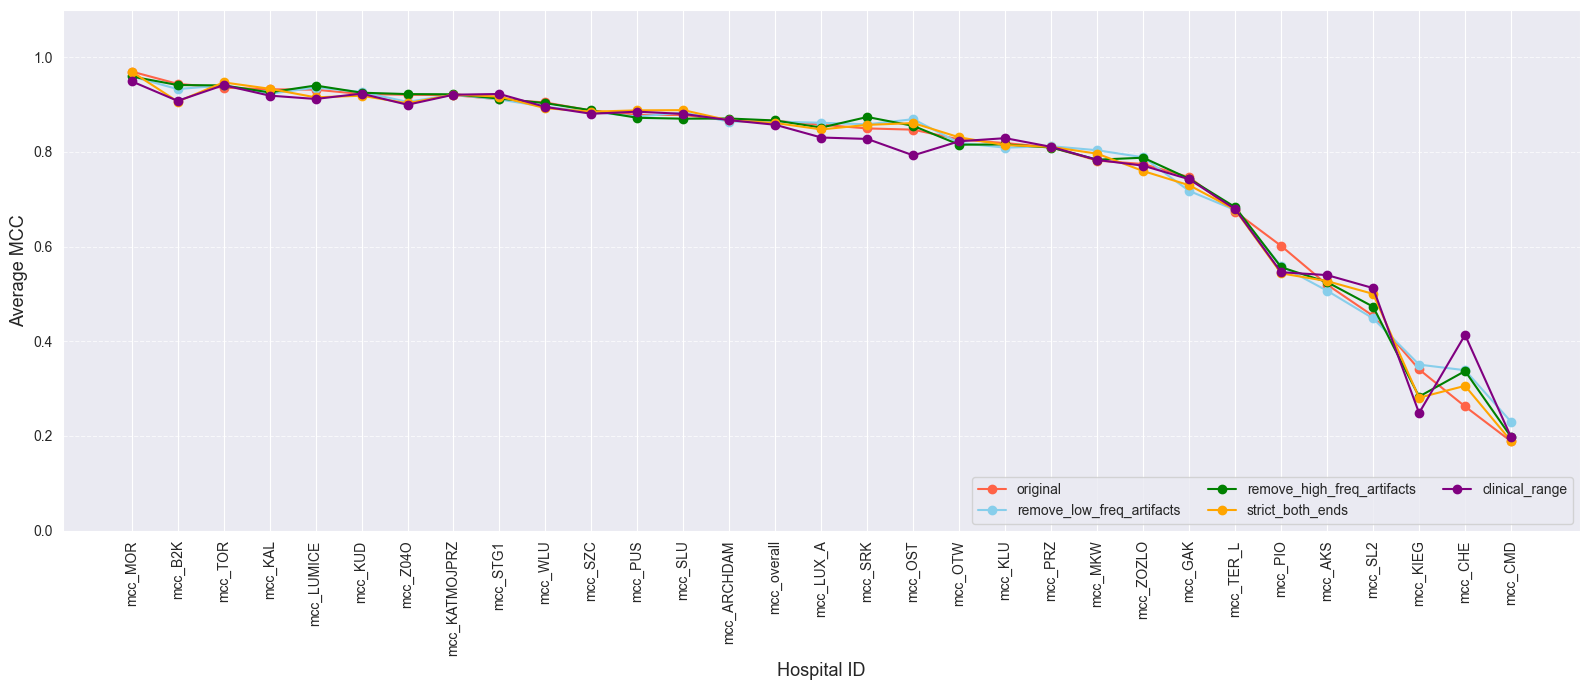

In [5]:
os.makedirs(FIGURES_DIR, exist_ok=True)

reference_series = mean_results_df.loc['original']
sort_idx = reference_series.values.argsort()[::-1]
class_labels_sorted = reference_series.index.values[sort_idx]

fig, ax = plt.subplots(figsize=(16, 7))
for i, tag in enumerate(FEATURES):
    values = [mean_results_df.loc[tag].get(h, np.nan) for h in class_labels_sorted]
    ax.plot(class_labels_sorted, values, marker='o', linestyle='-',
            color=COLOR_GRID[i], label=tag)

ax.set_ylabel('Average MCC', fontsize=13)
ax.set_xlabel('Hospital ID', fontsize=13)
ax.tick_params(axis='x', rotation=90)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='lower right', fontsize=10, ncol=3)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/site_mcc_per_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

## Overall MCC bar chart

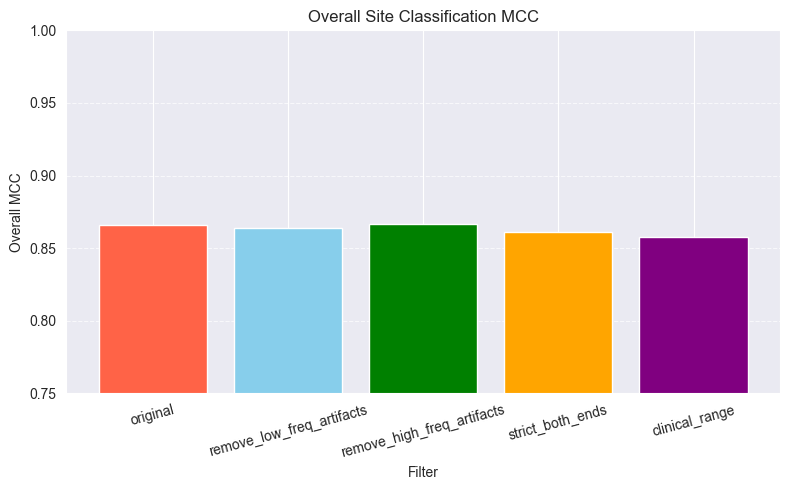

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
overall = mean_results_df['mcc_overall'].reindex(FEATURES)
ax.bar(FEATURES, overall, color=COLOR_GRID[:len(FEATURES)])
ax.set_title('Overall Site Classification MCC')
ax.set_ylabel('Overall MCC')
ax.set_xlabel('Filter')
ax.tick_params(axis='x', rotation=15)
ax.set_ylim(0.75, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/site_mcc_overall_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Analysis

> **Server only** — requires saved pipelines and test data from `models/` and `results/shap_data/`

In [ ]:
RUN = False
if RUN:
    pipelines = {}
    test_data = {}
    method = 'raw'
    for filter_tag in FEATURES:
        key = f'{method}_{filter_tag}'
        pipeline_path = os.path.join(PIPELINE_SAVE_DIR, f'{method}_{filter_tag}_pipeline_fold0.joblib')
        pipelines[key] = joblib.load(pipeline_path)

        data_path = os.path.join(SHAP_DATA_SAVE_DIR, f'{method}_{filter_tag}_test_data_fold0.parquet')
        test_data[key] = pd.read_parquet(data_path)

In [ ]:
if RUN:
    shap_values = {}
    X_shap = {}
    method = 'raw'
    for filter_tag in FEATURES:
        key = f'{method}_{filter_tag}'
        X_test = test_data[key].drop(columns=['y_true_hospital'])
        shap_values[key], X_shap[key] = compute_shap_from_pipeline(pipelines[key], X_test)
        logging.info(f'SHAP done: {key}')

In [ ]:
if RUN:
    os.makedirs(FIGURES_DIR, exist_ok=True)
    method = 'raw'
    for filter_tag in FEATURES:
        key = f'{method}_{filter_tag}'
        shap_series = shap_to_mean_series(shap_values[key])
        fig, axs = plot_eeg_feature_overview(
            features_series=shap_series,
            figure_title=f'Filter: {filter_tag}'
        )
        save_path = f'{FIGURES_DIR}/{key}_shap_overview.png'
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        logging.info(f'Saved: {save_path}')
        plt.close(fig)

In [ ]:
if RUN:
    method = 'raw'
    for filter_tag in FEATURES:
        key = f'{method}_{filter_tag}'
        model = pipelines[key].named_steps['clf']
        per_class = shap_to_per_class_series(shap_values[key], model.classes_)
        save_dir = f'{FIGURES_DIR}/{key}'
        os.makedirs(save_dir, exist_ok=True)
        for hospital_id, shap_series in per_class.items():
            fig, axs = plot_eeg_feature_overview(
                features_series=shap_series,
                figure_title=f'Filter: {filter_tag}, Hospital: {hospital_id}'
            )
            fig.savefig(f'{save_dir}/{key}_{hospital_id}_shap_overview.png',
                        dpi=150, bbox_inches='tight')
            plt.close(fig)
        logging.info(f'Per-class SHAP saved: {filter_tag}')